<a href="https://colab.research.google.com/github/silviaparente/computational_astrobiology/blob/main/Copia_di_random_forest_exoplanets_nasa_archive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest on Real Exoplanet Data from the NASA Exoplanet Archive
**Master-level Colab exercise**

This notebook is designed as a serious, end-to-end machine-learning exercise using **real exoplanet data** from the **NASA Exoplanet Archive**.

## Scientific goal
We will build a **Random Forest classifier** to predict a planet **radius class** using orbital and stellar features from confirmed exoplanets.

## Why this is a good exercise
It combines:
- real astronomical data retrieval from a live archive,
- scientific feature selection,
- missing-data handling,
- class-definition choices,
- supervised classification,
- cross-validation,
- confusion-matrix analysis,
- permutation importance,
- discussion of selection effects and astrophysical caveats.

## Learning objectives
By the end of this notebook, students should be able to:
1. Query the NASA Exoplanet Archive programmatically.
2. Build a clean tabular exoplanet dataset.
3. Define a physically motivated classification target.
4. Train and evaluate a Random Forest model.
5. Interpret feature importance critically.
6. Distinguish between predictive success and astrophysical causation.

---

## Target definition used here
We define the target `planet_class` from the **planet radius** `pl_rade`:

- `rocky`: \( R_p < 1.8\,R_\oplus \)
- `sub_neptune`: \(1.8 \le R_p < 4.0\,R_\oplus\)
- `giant`: \( R_p \ge 4.0\,R_\oplus \)

These are approximate and pedagogical boundaries, not immutable physical laws.

We will **not** use `pl_rade` itself as an input feature, because that would cause target leakage.

---

## Exercise philosophy
This notebook is partly guided and partly open-ended.  
You can run it as-is, but several sections are deliberately framed as **student tasks**.

## 0. Recommended discussion before running any code

### Question 1
Why is it scientifically risky to use every available column from the archive without thinking?

### Question 2
Why would using `pl_rade` as an input feature make the exercise meaningless if the target is derived from `pl_rade`?

### Question 3
Why might the final classifier reflect **discovery biases** as well as planet physics?

In [1]:
# Core scientific Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from urllib.parse import quote

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Retrieve real data from the NASA Exoplanet Archive

We use the **`pscomppars`** table, which provides one row per planet and is often the most convenient table for statistical work.

### Why `pscomppars`?
- one row per planet,
- reasonably complete for population-level analysis,
- includes planet + host star parameters in one record.

We will request only a selected subset of columns to keep the exercise focused.

In [2]:
BASE = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = '''
select
    pl_name,
    hostname,
    discoverymethod,
    disc_year,
    pl_orbper,
    pl_orbsmax,
    pl_orbeccen,
    pl_bmasse,
    pl_dens,
    pl_eqt,
    pl_insol,
    pl_rade,
    st_teff,
    st_rad,
    st_mass,
    st_met,
    st_logg,
    sy_dist,
    sy_vmag,
    sy_kmag
from pscomppars
where pl_rade is not null
'''

url = f"{BASE}?query={quote(query)}&format=csv"
print(url)

https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=%0Aselect%0A%20%20%20%20pl_name%2C%0A%20%20%20%20hostname%2C%0A%20%20%20%20discoverymethod%2C%0A%20%20%20%20disc_year%2C%0A%20%20%20%20pl_orbper%2C%0A%20%20%20%20pl_orbsmax%2C%0A%20%20%20%20pl_orbeccen%2C%0A%20%20%20%20pl_bmasse%2C%0A%20%20%20%20pl_dens%2C%0A%20%20%20%20pl_eqt%2C%0A%20%20%20%20pl_insol%2C%0A%20%20%20%20pl_rade%2C%0A%20%20%20%20st_teff%2C%0A%20%20%20%20st_rad%2C%0A%20%20%20%20st_mass%2C%0A%20%20%20%20st_met%2C%0A%20%20%20%20st_logg%2C%0A%20%20%20%20sy_dist%2C%0A%20%20%20%20sy_vmag%2C%0A%20%20%20%20sy_kmag%0Afrom%20pscomppars%0Awhere%20pl_rade%20is%20not%20null%0A&format=csv


In [3]:
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (6248, 20)


,pl_name,hostname,discoverymethod,disc_year,pl_orbper,pl_orbsmax,pl_orbeccen,pl_bmasse,pl_dens,pl_eqt,pl_insol,pl_rade,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag,sy_kmag
0,Kepler-1167 b,Kepler-1167,Transit,2016.0,1.003934,0.01750,0.0,3.570,3.92,1419.0,1039.697,1.710000,4971.0,0.750,0.790,-0.05,4.600,820.905,16.0470,13.663
1,Kepler-1740 b,Kepler-1740,Transit,2021.0,8.172400,0.07790,0.0,11.000,1.65,858.0,127.950,3.323214,5705.0,0.905,0.943,-0.06,4.499,1061.770,15.4540,13.695
2,Kepler-1581 b,Kepler-1581,Transit,2016.0,6.283855,0.06865,0.0,0.437,4.69,1108.0,470.862,0.800000,6022.0,1.230,1.120,0.07,4.310,493.175,12.4420,11.025
3,Kepler-644 b,Kepler-644,Transit,2016.0,3.173917,0.04641,0.0,10.100,1.78,1655.0,2381.770,3.150000,6747.0,1.810,1.490,0.08,4.090,1318.050,14.0310,12.574
4,Kepler-1752 b,Kepler-1752,Transit,2021.0,56.358501,0.26980,0.0,18.700,1.10,419.0,7.290,4.540605,5446.0,0.821,0.824,-0.20,4.525,962.888,16.0249,13.999


## 2. Initial scientific audit

Before modelling, always inspect:
- sample size,
- missing values,
- feature ranges,
- obvious outliers,
- class definition feasibility.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6248 entries, 0 to 6247
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6248 non-null   object 
 1   hostname         6248 non-null   object 
 2   discoverymethod  6248 non-null   object 
 3   disc_year        6247 non-null   float64
 4   pl_orbper        5911 non-null   float64
 5   pl_orbsmax       5831 non-null   float64
 6   pl_orbeccen      5208 non-null   float64
 7   pl_bmasse        6224 non-null   float64
 8   pl_dens          6156 non-null   float64
 9   pl_eqt           4681 non-null   float64
 10  pl_insol         4407 non-null   float64
 11  pl_rade          6248 non-null   float64
 12  st_teff          5955 non-null   float64
 13  st_rad           5934 non-null   float64
 14  st_mass          6241 non-null   float64
 15  st_met           5614 non-null   float64
 16  st_logg          5930 non-null   float64
 17  sy_dist       

In [5]:
missing = df.isna().mean().sort_values(ascending=False)
missing.to_frame("missing_fraction").head(20)

,missing_fraction
pl_insol,0.294654
pl_eqt,0.250800
pl_orbeccen,0.166453
st_met,0.101472
pl_orbsmax,0.066741
pl_orbper,0.053937
st_logg,0.050896
st_rad,0.050256
sy_vmag,0.047535
st_teff,0.046895


In [6]:
# Basic descriptive statistics for numeric columns
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
disc_year,6247.0,2017.217384,5.077604e+00,1992.000000,2014.000000,2016.000000,2021.000000,2.026000e+03
pl_orbper,5911.0,72410.659341,5.231169e+06,0.112007,4.301441,10.676072,37.917740,4.020000e+08
pl_orbsmax,5831.0,15.708122,3.491311e+02,0.005000,0.052200,0.102000,0.302920,1.900000e+04
pl_orbeccen,5208.0,0.078945,1.527541e-01,0.000000,0.000000,0.000000,0.090000,9.500000e-01
pl_bmasse,6224.0,389.424889,1.120373e+03,0.020000,4.270000,9.100000,174.805843,9.534852e+03
pl_dens,6156.0,4.837506,3.414242e+01,0.005100,1.290000,2.525000,4.540000,2.000000e+03
pl_eqt,4681.0,915.137552,4.629903e+02,34.000000,569.000000,824.000000,1164.000000,4.050000e+03
pl_insol,4407.0,419.861776,1.286788e+03,0.000300,24.100000,100.000000,376.375650,4.490000e+04
pl_rade,6248.0,5.814146,5.407920e+00,0.309800,1.840000,2.846633,11.900000,8.720587e+01
st_teff,5955.0,5383.232054,1.664932e+03,415.000000,4895.985000,5544.000000,5898.000000,5.700000e+04


## 3. Define the target classes from planetary radius

We create a 3-class target:
- rocky
- sub_neptune
- giant

In [7]:
def radius_to_class(r):
    if pd.isna(r):
        return np.nan
    if r < 1.8:
        return "rocky"
    elif r < 4.0:
        return "sub_neptune"
    else:
        return "giant"

df["planet_class"] = df["pl_rade"].apply(radius_to_class)
df["planet_class"].value_counts(dropna=False)

,count
planet_class,
giant,2400
sub_neptune,2346
rocky,1502


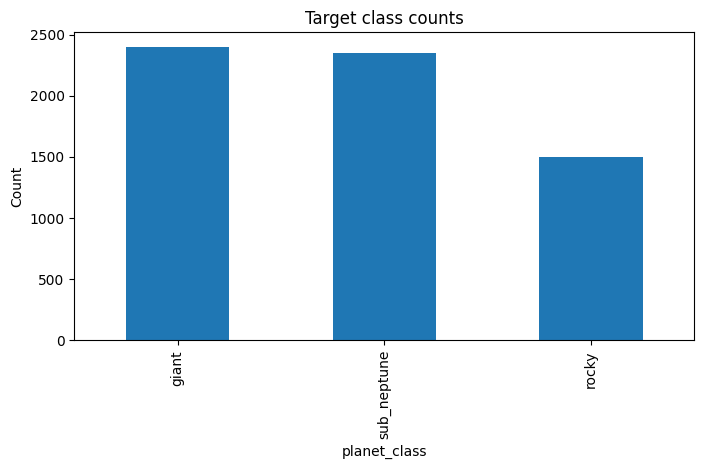

In [8]:
ax = df["planet_class"].value_counts().plot(kind="bar", figsize=(8,4))
ax.set_title("Target class counts")
ax.set_ylabel("Count")
plt.show()

### Student task
Inspect the class balance.  
Is this balanced enough for naive accuracy to be meaningful?

**Hint:** In imbalanced classification, balanced accuracy and macro-F1 are often more informative than plain accuracy.

## 4. Choose input features

We **exclude**
- `pl_rade` because it defines the target,
- names/identifiers because they do not represent physics,
- host names because they are identifiers rather than predictive variables.

We keep a compact physically interpretable set of orbital, planetary, and stellar quantities.

In [9]:
feature_cols = [
    "pl_orbper",   # orbital period [days]
    "pl_orbsmax",  # semi-major axis [AU]
    "pl_orbeccen", # eccentricity
    "pl_bmasse",   # planet mass or M*sin(i) [Earth masses]
    "pl_dens",     # density [g/cm^3]
    "pl_eqt",      # equilibrium temperature [K]
    "pl_insol",    # insolation flux [Earth flux]
    "st_teff",     # stellar effective temperature [K]
    "st_rad",      # stellar radius [Solar radii]
    "st_mass",     # stellar mass [Solar masses]
    "st_met",      # metallicity [dex]
    "st_logg",     # stellar surface gravity
    "sy_dist",     # distance [pc]
    "sy_vmag",     # V magnitude
    "sy_kmag",     # K magnitude
]

target_col = "planet_class"

data = df[feature_cols + [target_col]].copy()
data.head()

,pl_orbper,pl_orbsmax,pl_orbeccen,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag,sy_kmag,planet_class
0,1.003934,0.01750,0.0,3.570,3.92,1419.0,1039.697,4971.0,0.750,0.790,-0.05,4.600,820.905,16.0470,13.663,rocky
1,8.172400,0.07790,0.0,11.000,1.65,858.0,127.950,5705.0,0.905,0.943,-0.06,4.499,1061.770,15.4540,13.695,sub_neptune
2,6.283855,0.06865,0.0,0.437,4.69,1108.0,470.862,6022.0,1.230,1.120,0.07,4.310,493.175,12.4420,11.025,rocky
3,3.173917,0.04641,0.0,10.100,1.78,1655.0,2381.770,6747.0,1.810,1.490,0.08,4.090,1318.050,14.0310,12.574,sub_neptune
4,56.358501,0.26980,0.0,18.700,1.10,419.0,7.290,5446.0,0.821,0.824,-0.20,4.525,962.888,16.0249,13.999,giant


## 5. Optional astrophysical filtering

Archive tables may include heterogeneous measurement quality and strong incompleteness.

For a pedagogical first pass, we keep the dataset fairly broad.  
But for a stricter scientific analysis, students may wish to require:
- non-null mass,
- non-null equilibrium temperature,
- bounded eccentricity,
- removal of extreme outliers.

Below we do only minimal sanity filtering.

In [10]:
# Remove obviously problematic or non-physical values in a conservative way
data = data.copy()
data = data[(data["pl_orbper"].isna()) | (data["pl_orbper"] > 0)]
data = data[(data["pl_orbsmax"].isna()) | (data["pl_orbsmax"] > 0)]
data = data[(data["pl_bmasse"].isna()) | (data["pl_bmasse"] > 0)]
data = data[(data["st_mass"].isna()) | (data["st_mass"] > 0)]
data = data[(data["st_rad"].isna()) | (data["st_rad"] > 0)]
data = data[(data["sy_dist"].isna()) | (data["sy_dist"] > 0)]

print("Filtered shape:", data.shape)
data[target_col].value_counts()

Filtered shape: (6248, 16)


,count
planet_class,
giant,2400
sub_neptune,2346
rocky,1502


## 6. Quick exploratory plots

We will inspect a few astrophysically relevant relationships.

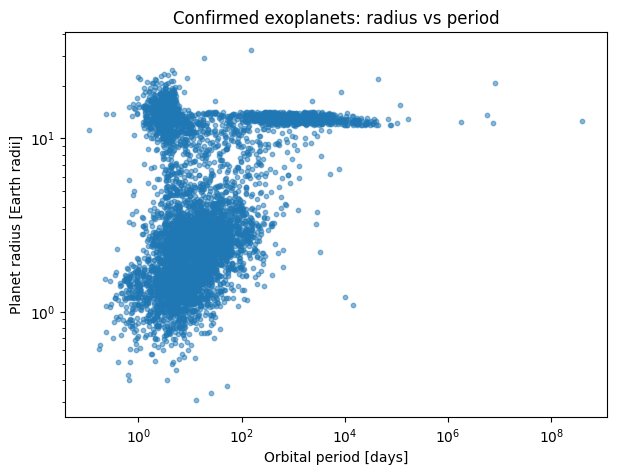

In [11]:
plot_df = df.copy()

plt.figure(figsize=(7,5))
mask = plot_df["pl_orbper"].notna() & plot_df["pl_rade"].notna()
plt.scatter(plot_df.loc[mask, "pl_orbper"], plot_df.loc[mask, "pl_rade"], s=10, alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Orbital period [days]")
plt.ylabel("Planet radius [Earth radii]")
plt.title("Confirmed exoplanets: radius vs period")
plt.show()

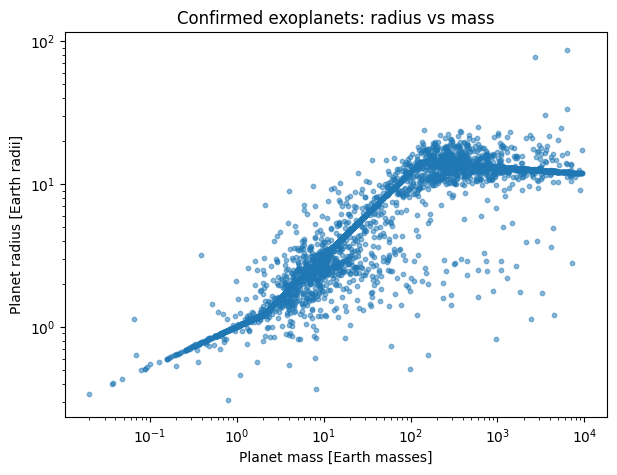

In [12]:
plt.figure(figsize=(7,5))
mask = plot_df["pl_bmasse"].notna() & plot_df["pl_rade"].notna()
plt.scatter(plot_df.loc[mask, "pl_bmasse"], plot_df.loc[mask, "pl_rade"], s=10, alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Planet mass [Earth masses]")
plt.ylabel("Planet radius [Earth radii]")
plt.title("Confirmed exoplanets: radius vs mass")
plt.show()

### Student task
From the two plots above, answer:
1. Which relation looks more directly predictive of radius class?
2. Which relation is likely to be affected more strongly by discovery bias?
3. Would you expect `pl_bmasse` to dominate feature importance? Why or why not?

## 7. Train-test split

We perform a stratified split so the class proportions are preserved.

In [13]:
X = data[feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (4686, 15)
Test shape: (1562, 15)

Training class distribution:
planet_class
giant          0.384123
sub_neptune    0.375587
rocky          0.240290
Name: proportion, dtype: float64

Test class distribution:
planet_class
giant          0.384123
sub_neptune    0.375160
rocky          0.240717
Name: proportion, dtype: float64


## 8. Build the preprocessing + model pipeline

Random Forest does **not** require feature scaling, but it does require a strategy for missing values.

We therefore use:
- median imputation for all numeric columns,
- RandomForestClassifier for the model.

We also use `class_weight="balanced_subsample"` to reduce the effect of class imbalance.

In [14]:
numeric_features = feature_cols

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    min_samples_split=6,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf)
])

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['pl_orbper', 'pl_orbsmax',
                                                   'pl_orbeccen', 'pl_bmasse',
                                                   'pl_dens', 'pl_eqt',
                                                   'pl_insol', 'st_teff',
                                                   'st_rad', 'st_mass',
                                                   'st_met', 'st_logg',
                                                   'sy_dist', 'sy_vmag',
                                                   'sy_kmag'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=3, min_samples_split=6,
                                        n_estimators=500, n_jobs=-1,
                                        random_state=42))])

## 9. Cross-validation on the training set

We evaluate with:
- balanced accuracy,
- macro F1,
- weighted F1.

This is better than relying on one train/test split alone.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted"
    },
    n_jobs=-1,
    return_train_score=False
)

pd.DataFrame(cv_results)

,fit_time,score_time,test_balanced_accuracy,test_f1_macro,test_f1_weighted
0,5.612775,0.184947,0.966899,0.968978,0.969133
1,5.907868,0.135493,0.966145,0.966422,0.965834
2,6.555115,0.157247,0.971107,0.972945,0.973309
3,6.562720,0.165950,0.965509,0.967085,0.966941
4,3.296432,0.123932,0.972155,0.973776,0.973321


In [16]:
summary = pd.DataFrame({
    metric: [np.mean(values), np.std(values)]
    for metric, values in cv_results.items()
    if metric.startswith("test_")
}, index=["mean", "std"]).T

summary

,mean,std
test_balanced_accuracy,0.968363,0.002725
test_f1_macro,0.969841,0.003005
test_f1_weighted,0.969708,0.003131


### Student task
Interpret the difference between:
- macro F1
- weighted F1
- balanced accuracy

Which one is most appropriate if the rarest class is scientifically important?

## 10. Fit final model and evaluate on the test set

In [17]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print()
print(classification_report(y_test, y_pred))

Balanced accuracy: 0.9678505555152132
Macro F1: 0.9704768471192571
Weighted F1: 0.9711887102119586

              precision    recall  f1-score   support

       giant       0.98      0.98      0.98       600
       rocky       0.99      0.94      0.97       376
 sub_neptune       0.95      0.97      0.96       586

    accuracy                           0.97      1562
   macro avg       0.97      0.97      0.97      1562
weighted avg       0.97      0.97      0.97      1562



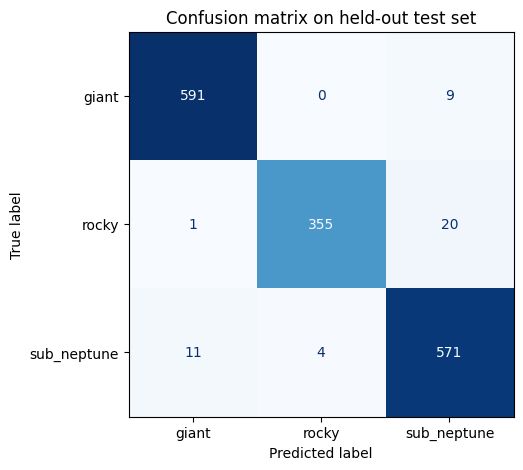

In [18]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix on held-out test set")
plt.show()

## 11. Permutation importance

Tree-based impurity importance can be biased, so we also compute **permutation importance** on the test set.

This is often more trustworthy for interpretation.

In [19]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="balanced_accuracy",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df

,feature,importance_mean,importance_std
3,pl_bmasse,0.440879,0.008039
4,pl_dens,0.209541,0.009221
1,pl_orbsmax,0.002522,0.001232
5,pl_eqt,0.000329,0.001345
0,pl_orbper,0.000288,0.001330
13,sy_vmag,-0.000196,0.001015
6,pl_insol,-0.000268,0.001207
2,pl_orbeccen,-0.000355,0.001031
8,st_rad,-0.000770,0.000776
12,sy_dist,-0.001164,0.000278


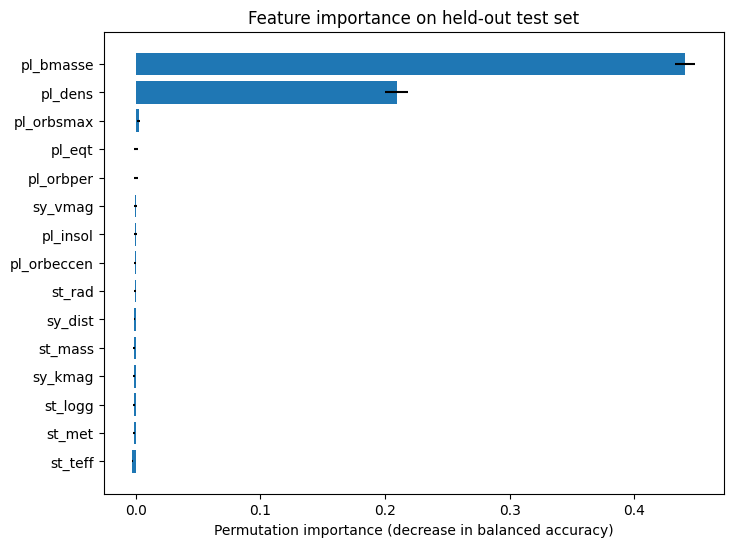

In [20]:
plt.figure(figsize=(8,6))
plt.barh(importance_df["feature"], importance_df["importance_mean"], xerr=importance_df["importance_std"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation importance (decrease in balanced accuracy)")
plt.title("Feature importance on held-out test set")
plt.show()

### Student task
Discuss the top-ranked features:

1. Are they physically plausible?
2. Could any of them be proxies for detection bias rather than intrinsic planet structure?
3. Would the ranking change if you removed `pl_bmasse` or `pl_dens`?

## 12. Optional extension: compare two feature sets

A useful scientific exercise is to compare:

### Model A
All selected features

### Model B
Only stellar + orbital features  
(excluding direct planet-structure features such as `pl_bmasse` and `pl_dens`)

This tests how much of the classification depends on direct structural information versus environment.

In [21]:
feature_cols_B = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_orbeccen",
    "pl_eqt",
    "pl_insol",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "st_logg",
    "sy_dist",
    "sy_vmag",
    "sy_kmag",
]

X_B = data[feature_cols_B]
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), feature_cols_B)
    ]
)

model_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        min_samples_split=6,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

cv_results_B = cross_validate(
    model_B,
    X_train_B,
    y_train_B,
    cv=cv,
    scoring={
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted"
    },
    n_jobs=-1
)

summary_B = pd.DataFrame({
    metric: [np.mean(values), np.std(values)]
    for metric, values in cv_results_B.items()
    if metric.startswith("test_")
}, index=["mean", "std"]).T

summary_B

,mean,std
test_balanced_accuracy,0.714519,0.013620
test_f1_macro,0.716185,0.014877
test_f1_weighted,0.729838,0.013802


### Compare the two models
If Model A substantially outperforms Model B, that likely means direct planet-structure features carry much of the predictive signal. That is not surprising, but it is scientifically useful to quantify.

This comparison also opens a very good classroom discussion:
> Is the model learning a physically deep relation, or is it largely exploiting nearby observables?

## 13. Optional extension: regression instead of classification

A strong extension for advanced students is to switch from classification to regression and predict:
- `pl_bmasse`, or
- `pl_eqt`, or
- `pl_dens`

using `RandomForestRegressor`.

Students can then compare:
- RMSE / MAE,
- residual plots,
- feature importance,
- regression versus classification framing.

## 14. Scientific caveats students must mention in their report

Any serious report should discuss the following:

### 1. Archive heterogeneity
The confirmed exoplanet sample is not a homogeneous survey product.

### 2. Selection effects
Transit, radial velocity, imaging, microlensing, and timing methods probe different regions of parameter space.

### 3. Missing-data mechanism
Missingness is not necessarily random.

### 4. Target construction
The class boundaries (`1.8` and `4.0` Earth radii) are pedagogical approximations.

### 5. Feature leakage risk
Always verify that target-defining quantities are not indirectly reintroduced.

### 6. Prediction is not causation
A strong classifier does not prove that the top feature is a causal driver.

## 15. Suggested student report questions

1. How many planets were retrieved from the archive at the time you ran the notebook?
2. What was the class distribution?
3. Which features had the highest permutation importance?
4. Which class was hardest to classify, and why?
5. How did the reduced-feature model compare to the full model?
6. Which astrophysical or observational biases may affect the conclusions?
7. What would you change to make the analysis more scientifically rigorous?

In [22]:
#challenge a: simplify the Planet Categories
#Instead of three categories, simplify it to a binary "Small vs. Giant" problem.

# 1. Create the new binary target
data['is_giant'] = (data['pl_rade'] >= 4.0).astype(int)

# 2. Update y and re-split
y_binary = data['is_giant']
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X, y_binary, test_size=0.25, random_state=42, stratify=y_binary
)

# 3. Re-train the model
model.fit(X_train_A, y_train_A)
print(f"Binary Classification Accuracy: {model.score(X_test_A, y_test_A):.4f}")

KeyError: 'pl_rade'

In [ ]:
#challenge b: The "Transit Only" Filter
#This test sees if the model works better when we only look at one type of telescope data.

# 1. Filter the dataset
transit_only_data = data[data['discoverymethod'] == 'Transit']

# 2. Re-run the split and fit using this smaller, more specific group
X_transit = transit_only_data[feature_cols]
y_transit = transit_only_data['planet_class'] # using original 3 classes
# (Proceed with train_test_split and model.fit)

In [ ]:
#challenge c: Predicting Discovery Method
#guess how a planet was found just by looking at its orbit and its star

#1. Set the target to the discovery method
y_method = data['discoverymethod']

# 2. Filter out rare methods so the model doesn't get confused
top_methods = y_method.value_counts().head(2).index
mask = y_method.isin(top_methods)
X_C = data[mask][feature_cols]
y_C = y_method[mask]

# 3. Train the model to see if it can distinguish 'Transit' from 'Radial Velocity'

## 16. Challenge problems

### Challenge A
Replace the target with a binary label:
- `small_planet` if `pl_rade < 4`
- `giant_planet` otherwise

Compare performance with the 3-class problem.

### Challenge B
Restrict the dataset to only planets discovered by the transit method.  
Does performance improve or worsen?

### Challenge C
Train a model to predict `discoverymethod` from physical and stellar features.  
What does that teach you about selection effects?

### Challenge D
Use grouped cross-validation by `hostname` so planets in the same system do not leak between train and test.

### Challenge E
Compare Random Forest with:
- Logistic Regression
- XGBoost or HistGradientBoosting
- ExtraTreesClassifier

In [23]:
# --- INNOVATION: Visualizing Feature Distribution for Binary Classes ---
# This block plots the distribution of planet mass to see why giant planets can be trickier to bound.

# 1. Create the binary target (Small vs Giant) as mentioned in Challenge A
data_binary = data.copy()
data_binary['is_giant'] = (data_binary['pl_rade'] >= 4.0).astype(int)

fig, ax = plt.subplots(figsize=(8, 6))

# 2. Plot the mass distribution for Small Planets (Class 0)
# Using log10 because mass spans several orders of magnitude
ax.hist(np.log10(data_binary[data_binary['is_giant'] == 0]['pl_bmasse'].dropna()),
        bins=40, alpha=0.5, color='blue', label='Small Planets (Radius < 4.0)')

# 3. Plot the mass distribution for Giant Planets (Class 1)
ax.hist(np.log10(data_binary[data_binary['is_giant'] == 1]['pl_bmasse'].dropna()),
        bins=40, alpha=0.7, color='orange', label='Giant Planets (Radius >= 4.0)')

ax.set_xlabel("Log10(Planet Mass [Earth Masses])")
ax.set_ylabel("Number of Planets")
ax.set_title("Feature Overlap: Planet Mass Distribution")
ax.legend()

plt.show()

print("Observation: The mass of giant planets spans a very wide range and overlaps slightly with small planets.")
print("This massive spread explains why simple splits might struggle and why an advanced model might be needed.")

KeyError: 'pl_rade'